# CSDS 340, Case Study 1
**Group Number:** 14  
**Members:** Ishika Mishra & Kelly Gorman

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

This section loads the training data from the 'Apple Quality' CSV from Kaggle. We also load our necesarry imports such as numpy & pandas, but also everything necesarry from hyperparameter tuning and to run each of these models.

In [7]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier


RANDOM_SEED = 101
TRAIN_PATH  = "Data/train.csv"
TEST_PATH   = "Data/test.csv"

# TRAIN_PATH = "/content/drive/My Drive/CSDS340/Data/train.csv"
# TEST_PATH  = "/content/drive/My Drive/CSDS340/Data/test.csv"

np.random.seed(RANDOM_SEED)

## Data processing

In [8]:
# load training data
data = pd.read_csv(TRAIN_PATH)

# features 0-6 cols
X = data.iloc[:, :-1].to_numpy()
# label 7 col
y = data.iloc[:, -1].to_numpy()

print(f"Training set shape — X: {X.shape}, y: {y.shape}")

Training set shape — X: (3200, 7), y: (3200,)


We load the dataset as a pandas datafram which is necesarry to run all of our models. At this point we can see that there are 7 features and 1 label.

In [9]:

print("first 5 rows of dataset:")
display(data.head())

print("data types / number of non null values:")
display(data.info())

print("missing values per column:")
print(data.isnull().sum())

print("descriptive statistics")
display(data.describe())

first 5 rows of dataset:


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.133243,-1.474148,0.047767,2.825380,1.985239,0.996645,0.216463,1
1,0.764803,-4.278192,-3.225880,2.239121,-1.491259,6.134522,-2.587893,0
2,0.955259,-3.638162,-0.728257,0.326915,0.456008,-0.581193,-0.969690,1
3,-2.186439,-0.829629,2.286444,2.480696,-3.498058,-1.960518,2.843064,0
4,2.682281,0.897649,-1.023634,2.244069,-0.301777,-2.576000,0.629952,0


data types / number of non null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         3200 non-null   float64
 1   Weight       3200 non-null   float64
 2   Sweetness    3200 non-null   float64
 3   Crunchiness  3200 non-null   float64
 4   Juiciness    3200 non-null   float64
 5   Ripeness     3200 non-null   float64
 6   Acidity      3200 non-null   float64
 7   Quality      3200 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 200.1 KB


None

missing values per column:
Size           0
Weight         0
Sweetness      0
Crunchiness    0
Juiciness      0
Ripeness       0
Acidity        0
Quality        0
dtype: int64
descriptive statistics


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
count,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,-0.509964,-0.975105,-0.448321,0.974864,0.518305,0.464734,0.067925,0.505000
std,1.937959,1.599048,1.938369,1.402598,1.941229,1.871801,2.114830,0.500053
min,-7.151703,-6.581590,-6.359749,-6.055058,-5.961897,-5.864599,-7.010538,0.000000
25%,-1.830143,-1.991347,-1.731675,0.067410,-0.799721,-0.806292,-1.375641,0.000000
50%,-0.529601,-0.965996,-0.480036,0.983350,0.522682,0.473135,0.022683,1.000000
75%,0.779280,0.038554,0.826727,1.887107,1.867311,1.708247,1.487672,1.000000
max,5.866232,5.790714,5.862356,7.619852,7.364403,6.503375,7.404736,1.000000


We do not have any missing or null values for any of the features. For now, we can avoid imputation procedures.

In [10]:
# check class balance
counts = pd.Series(y).value_counts()
print("Class counts:")
print(counts)
print(f"\nClass balance — 0: {counts[0]/len(y)*100:.1f}%  |  1: {counts[1]/len(y)*100:.1f}%")

Class counts:
1    1616
0    1584
Name: count, dtype: int64

Class balance — 0: 49.5%  |  1: 50.5%


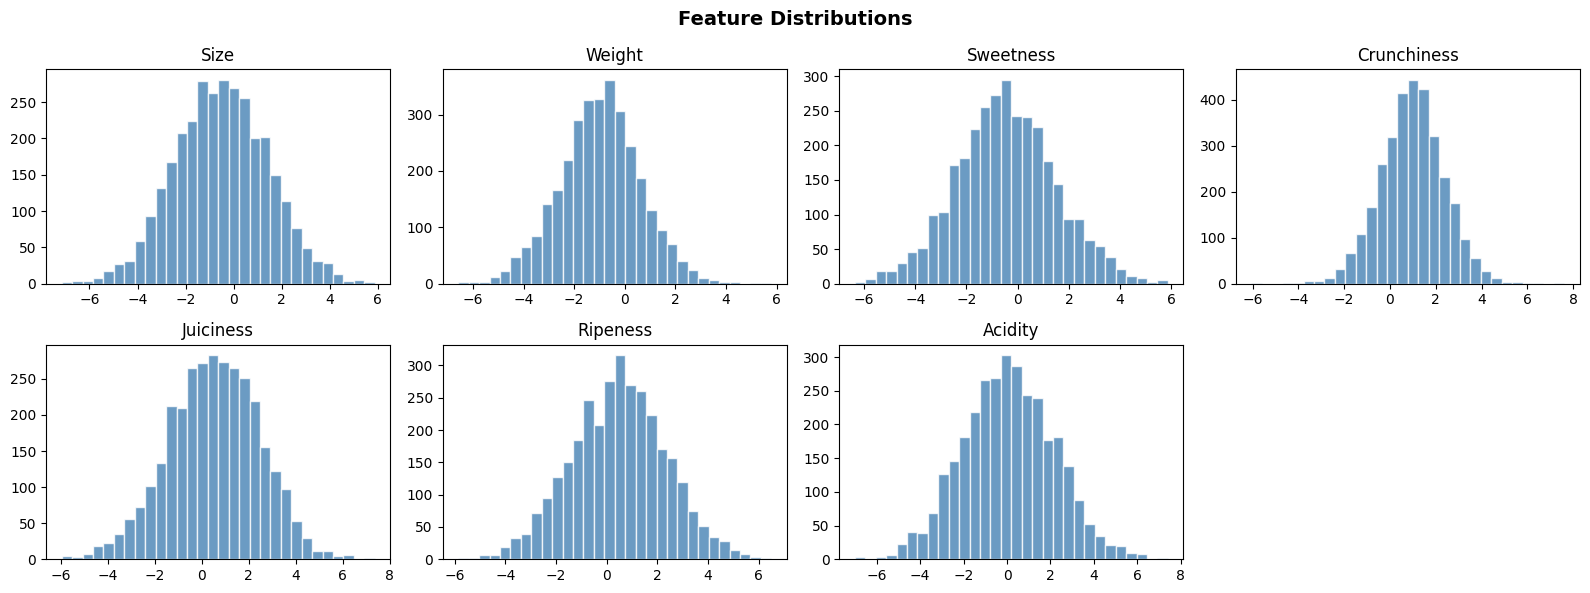

In [11]:
# check feature distributions
feature_names = list(data.columns[:-1])

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, name in enumerate(feature_names):
    axes[i].hist(data[name], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(name)
# only 7 features, 8 is labels
axes[-1].set_visible(False)
plt.suptitle("Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

By plotting the distributions of each of the features, we can see that they are all normally distributed.

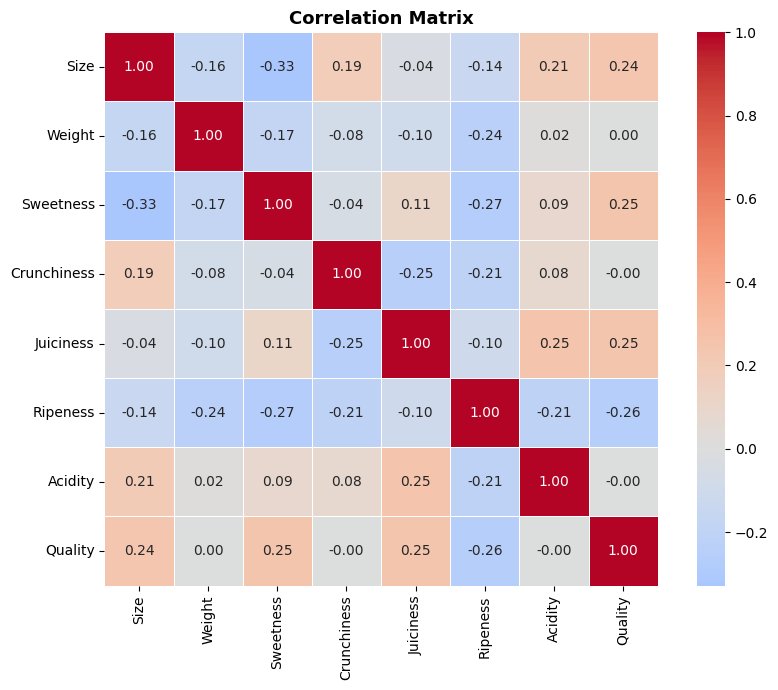

In [12]:
# correlation heat map to see if any features are highly correlated with each other or the target
plt.figure(figsize=(9, 7))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# looking for anything about ~0.6 that is not on the diagonal (which would be perfect correlation)

By plotting the correlations on this histogram, we can also see that no two features are too strongly correlated with each other. The highest magnitude of correlation is a -0.33 between size and sweetness. No features are also strongly correlated with Quality. This will make the classifciation task a little more difficult for linear models. There is also no class imbalance.

In [13]:
# standard scaler for feature scaling on features 0-6, NOT labels
scaler = StandardScaler()

# no need for min max since its nice to keep that center at 0 and std at 1 for logistic regression and SVM
X_scaled = scaler.fit_transform(X)

# decision tree doesnt need scaling but it cant hurt so keep for consistency.

Standard scaling of all the feature columns. We keep the min/max out of the scaling because the center of 0 and then the standard deviation of 1 is best for logistic regression and svm models.The standard scalar is especially important for SVM because it is distance based model. The standard scaling is also important for logistric regression to prevent larger feature values from dominating the regularization term. Decison tree does not need scaling but it will not be impacted if we keep the scaling across all models for consistency.

## Hyperparameter Tuning

**KNN**

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
#knn trial + error 50 times
k_values = range(1, 51)
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5,
        scoring='accuracy'
    )

    mean_score = scores.mean()
    cv_scores.append(mean_score)
    print(f"k = {k}, average CV accuracy = {mean_score:.4f}")

best_k = k_values[np.argmax(cv_scores)]
print("\nBest k from trial and error:", best_k)

k = 1, average CV accuracy = 0.8753
k = 2, average CV accuracy = 0.8600
k = 3, average CV accuracy = 0.8844
k = 4, average CV accuracy = 0.8766
k = 5, average CV accuracy = 0.8903
k = 6, average CV accuracy = 0.8866
k = 7, average CV accuracy = 0.8894
k = 8, average CV accuracy = 0.8884
k = 9, average CV accuracy = 0.8891
k = 10, average CV accuracy = 0.8925
k = 11, average CV accuracy = 0.8922
k = 12, average CV accuracy = 0.8878
k = 13, average CV accuracy = 0.8906
k = 14, average CV accuracy = 0.8897
k = 15, average CV accuracy = 0.8891
k = 16, average CV accuracy = 0.8866
k = 17, average CV accuracy = 0.8863
k = 18, average CV accuracy = 0.8866
k = 19, average CV accuracy = 0.8881
k = 20, average CV accuracy = 0.8872
k = 21, average CV accuracy = 0.8856
k = 22, average CV accuracy = 0.8859
k = 23, average CV accuracy = 0.8875
k = 24, average CV accuracy = 0.8866
k = 25, average CV accuracy = 0.8869
k = 26, average CV accuracy = 0.8856
k = 27, average CV accuracy = 0.8862
k = 28, av

In [15]:
# possible values of k to test for knn
k_values = [1, 3, 5, 7, 9, 11]
num_folds = 5

# fold splitter
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# avg score per k
results = {}

for k in k_values:
    fold_scores = []

    # training and validation folds
    for train_index, val_index in kf.split(X_scaled):
        X_fold_train = X_scaled[train_index]
        X_fold_val = X_scaled[val_index]

        y_fold_train = y[train_index]
        y_fold_val = y[val_index]

        # model with current k
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_fold_train, y_fold_train) # train on k-1 folds
        y_pred = model.predict(X_fold_val) # rredict on val fold
        score = accuracy_score(y_fold_val, y_pred) # how did it do?
        fold_scores.append(score)

    # avg  across all folds
    results[k] = np.mean(fold_scores)

print("avg cross val acc per k:")
for k, score in results.items():
    print(f"k = {k}: {score:.4f}")

# best
best_k = max(results, key=results.get)
print("Winner is.... k=", best_k)

avg cross val acc per k:
k = 1: 0.8719
k = 3: 0.8866
k = 5: 0.8866
k = 7: 0.8891
k = 9: 0.8922
k = 11: 0.8909
Winner is.... k= 9


**SVM**

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# svm model for grid search
svm_model = SVC()

# all combos for testing
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['rbf']
}

# grid search
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

#  cross-val on all parameter combos
grid_search.fit(X_scaled, y)

print("Best parameters found by Grid Search:")
print(grid_search.best_params_)

print("\nBest average cross-validation accuracy:")
print(round(grid_search.best_score_, 4))

Best parameters found by Grid Search:
{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

Best average cross-validation accuracy:
0.9031


In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

svm_model = SVC()

param_dist = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf']
}

random_search = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_dist,
    # test 50 random combos
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

random_search.fit(X_scaled, y)

print("Best parameters found by Randomized Search:")
print(random_search.best_params_)

print("\nBest average cross-validation accuracy:")
print(round(random_search.best_score_, 4))

print("this is actually the same result as grid search")

/Users/kellyg/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 30 is smaller than n_iter=50. Running 30 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters found by Randomized Search:
{'kernel': 'rbf', 'gamma': 0.1, 'C': 100}

Best average cross-validation accuracy:
0.9031
this is actually the same result as grid search


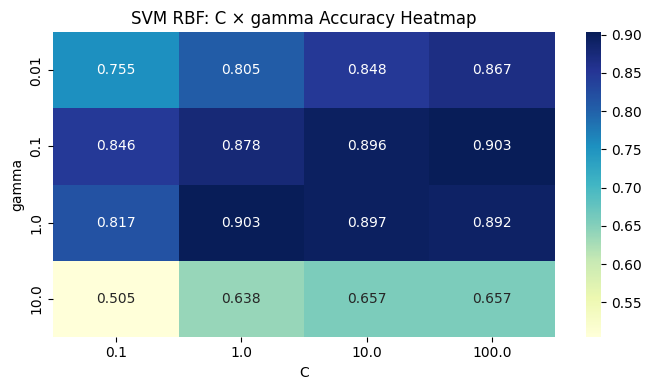

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#gridsearch -> df
svm_results = pd.DataFrame(grid_search.cv_results_)

#  RBF rows w/ number gamma
rbf_subset = svm_results[
    (svm_results['param_kernel'] == 'rbf') &
    (svm_results['param_gamma'].apply(lambda g: isinstance(g, (int, float))))
].copy()

if not rbf_subset.empty:
    rbf_subset['param_C'] = rbf_subset['param_C'].astype(float)
    rbf_subset['param_gamma'] = rbf_subset['param_gamma'].astype(float)

    pivot = rbf_subset.pivot(
        index='param_gamma',
        columns='param_C',
        values='mean_test_score'
    )

    plt.figure(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
    plt.title('SVM RBF: C × gamma Accuracy Heatmap')
    plt.xlabel('C')
    plt.ylabel('gamma')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric gamma values in RBF results to plot.")

We begin with the GridSearchCV. This exahustively tests every possible combination of hyperparameters. In this case, we tested all 16 combinations of C & gamma values. SVM is very senstivie to gamma & C paramters. The C controls the penalty for misclassificaiton where as gamma controls how far the influence of a single training point. The wrong combination can decrease the accuracy significantly. For example, in the heatmap the accuracy almost drops below 50% with a gamma value of 10. The heatmap is a good visualizer of how accuracy changes across C and gamma combination tested, which is especially helpful when looking at grid search results. GridSearchCV also uses 5 fold cross validation for each combination, which is usually much more accurate then just a single train/test split. GridSearchCV found that the best C=100 & gamma=0.1. Gamma=0.1 consistently perfomrs best across all C values and a very high gamma value causes the model to overfit, which leads to the accuracy dropping significnatly. Increasing C helps up to about C=100 but the gain flattens out from there. Using the best combination of C and gamma, we got an accuracy of 90.31% for the SVM model. RandomizedSearchCV also got the same C & gamma values. RandomizedSearchCV verified these results because it searches a much wider range of C and gamma values. It then randomly samples 50 combinations out of this wider range, and tests all of them. This verifies our results, showing that the size of the search space does not impact our c & gamma values, and it does not help find better c & gamma values. We also decided to use RBF over a linear kernel because their are strong hints at this point that the data is not linearly seperable. In our correlation matrix heatmap, no feature had a strong linear relationship with quality feature.

**LR**

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
# make parameter grid
lr_param_grid = {
    # reg strength
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    # supports both l1 and l2
    'solver':  ['liblinear'],
    }

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_scaled, y)

print(f"\nBest LR params:    {lr_grid.best_params_}")
print(f"Best LR CV score:  {lr_grid.best_score_*100:.2f}%")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best LR params:    {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best LR CV score:  74.44%


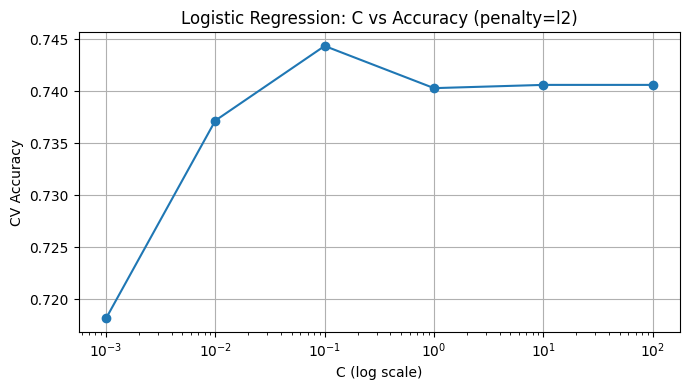

In [20]:
# C vs accuracy for best penalty
lr_results = pd.DataFrame(lr_grid.cv_results_)
best_penalty = lr_grid.best_params_['penalty']

subset = lr_results[lr_results['param_penalty'] == best_penalty]
plt.figure(figsize=(7, 4))
plt.plot(subset['param_C'].astype(float), subset['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('CV Accuracy')
plt.title(f'Logistic Regression: C vs Accuracy (penalty={best_penalty})')
plt.grid(True)
plt.tight_layout()
plt.show()

# peak appears to be at 10^-1 so this is best C value for logistic regression with l1 penalty.

In [21]:
# # Refined LR grid around the peak
# lr_param_grid_v2 = {
#     'C': [0.05, 0.08, 0.1, 0.12, 0.15, 0.2],
#     'penalty': ['l2'],
#     'solver': ['liblinear'],
#     'class_weight': ['balanced', None]
# }

# lr_grid_v2 = GridSearchCV(
#     LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
#     param_grid=lr_param_grid_v2,
#     cv=cv,
#     scoring='accuracy',
#     n_jobs=-1
# )
# lr_grid_v2.fit(X_scaled, y)
# print(f"Refined LR best params: {lr_grid_v2.best_params_}")
# print(f"Refined LR CV score:    {lr_grid_v2.best_score_*100:.2f}%")

# This changed the score from 74.44 to 74.47 so it did not make make much of a difference

GridSearchCV was used to find the best combination of C, penalty, and solver. The smaller the value of C, the stronger the regularization is and this prevents overfitting. A larger value of C will have the model fit the data more closely. Initially, there was a peak found at C=0.1, so then we ran a refined search run around that value to make sure we did not miss an option that would yield a higher accuracy. Grid search found that L2 performed better then L1, which leads us to conclude that all 7 features in the dataset contribute useful information that makes the model more accurate. L1 penalty could lead to some features having a 0 weight that contributes to the model. The C vs accuracy plot shows the accuracy having a steep rise at C=0.1 and then flattening out. The model stops improving with more complexity so we can be confident in using C=0.1 for the best parameter. The logistic regression accuracy hits a ceiling of 74.47%. Previous to the pruning at C=0.1, the accuracy was 74.44%. During the pruning process, liblinear was used as the solver because it supports L1 and L2 penalties, but I after I tried the pruning process there was not a significant change in accuracy so I decided to remove it. This leads us to beleive that the problem is within in the dataset and not our hyperparameter tuning. Based on our EDA and the performance of the SVM model and the use of the RBF kerner outperforming a linear kernel for the SVM model, we beleive that the data is not linearly seperarble and that is why the linear logistic regression models accuracy hits a ceiling of about 74%.

**Decision tree**

In [22]:
# parameter grid for decision tree
dt_param_grid = {
    'max_depth':        [3, 5, 7, 10, 15, None],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion':        ['gini', 'entropy'],
}

# grid search for decision tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_grid=dt_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_scaled, y)

print(f"\nBest DT params:   {dt_grid.best_params_}")
print(f"Best DT CV score: {dt_grid.best_score_*100:.2f}%")

Fitting 5 folds for each of 192 candidates, totalling 960 fits

Best DT params:   {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best DT CV score: 81.44%


In [23]:
# Cost-complexity pruning
dt_param_grid_v2 = {
    'criterion': ['gini'],
    'min_samples_split': [10],
    'min_samples_leaf': [4],
    'max_depth': [None],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01, 0.02]
}

dt_grid_v2 = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_grid=dt_param_grid_v2,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
dt_grid_v2.fit(X_scaled, y)
print(f"Refined DT best params: {dt_grid_v2.best_params_}")
print(f"Refined DT CV score:    {dt_grid_v2.best_score_*100:.2f}%")

Refined DT best params: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Refined DT CV score:    82.16%


/var/folders/rv/q52q8kmj0s558xpyhlshtzw00000gn/T/ipykernel_36899/3599820241.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  depth_subset['param_max_depth'] = depth_subset['param_max_depth'].fillna(99).astype(int)


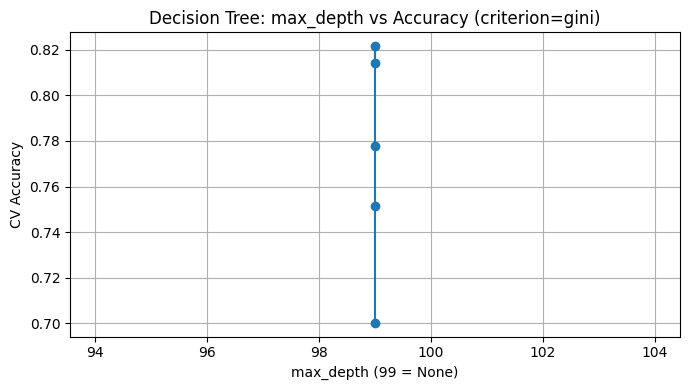

In [24]:
#  max_depth vs accuracy (for best criterion)
dt_results    = pd.DataFrame(dt_grid_v2.cv_results_)
best_criterion = dt_grid_v2.best_params_['criterion']

depth_subset = dt_results[
    (dt_results['param_criterion'] == best_criterion) &
    (dt_results['param_min_samples_split'] == dt_grid_v2.best_params_['min_samples_split']) &
    (dt_results['param_min_samples_leaf']  == dt_grid_v2.best_params_['min_samples_leaf'])
].copy()

depth_subset['param_max_depth'] = depth_subset['param_max_depth'].fillna(99).astype(int)
depth_subset = depth_subset.sort_values('param_max_depth')

plt.figure(figsize=(7, 4))
plt.plot(depth_subset['param_max_depth'], depth_subset['mean_test_score'], marker='o')
plt.xlabel('max_depth (99 = None)')
plt.ylabel('CV Accuracy')
plt.title(f'Decision Tree: max_depth vs Accuracy (criterion={best_criterion})')
plt.grid(True)
plt.tight_layout()
plt.show()

# note: should probably stop ~17 depth because that's pretty much where it flattens

Similar to the last two models, GridSearchCV was used to find the best combination of the following parameters. For decison trees, each parameter decides how the decison tree will be created. Max_depth limits how deep the tree grows, and this number can prevent the model from overfitting. Min_samples_split determines the minimumn samples need to split a node. Min_samples_leaf determines the the minimum samples required at a leaf node. Criterion determine how the tree measures the quality of the split, gini vs entropy. The higher the ccp_alpha is the pruning strength and the higher the value is the more branches are removed from the decison trees. This pruning helped because when the max_depth=None then the tree was allowed to grow with no limit, and this can cause overfitting. Before pruning the initial accuracy was 81.44% and after pruning the accuracy was 82.16%. The max_depth plot showed that the accuracy flattened out after about a max_depth=18 so a number close to that would be the best to use for our decison tree model. Even with the hyperparameter tuning, the decison tree model hit a ceiling of about 82%. This is probably better than the logistic regression model, but still worse than the SVM model. Because the data is not linearly seperable, a single tree can not completely capture the complexity of the data set.

---
## Section 4 — Model Comparison

In [25]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_summary = pd.DataFrame({
    'Model':      ['Logistic Regression', 'SVM', 'Decision Tree'],
    'Best CV Accuracy': [
        lr_grid.best_score_,
        svm_grid.best_score_,
        dt_grid_v2.best_score_
    ],
    'Best Params': [
        str(lr_grid.best_params_),
        str(svm_grid.best_params_),
        str(dt_grid_v2.best_params_)
    ]
})
results_summary['Best CV Accuracy'] = (results_summary['Best CV Accuracy'] * 100).round(2).astype(str) + '%'
display(results_summary)

# ── Bar chart ─────────────────────────────────────────────────────────────────
scores = [lr_grid.best_score_, svm_grid.best_score_, dt_grid_v2.best_score_]
models = ['Logistic Regression', 'SVM', 'Decision Tree']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, [s*100 for s in scores], color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
plt.ylim(min(scores)*100 - 2, 100)
plt.ylabel('Cross-Validation Accuracy (%)')
plt.title('Model Comparison — Best CV Accuracy')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{score*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'svm_grid' is not defined

Based on our results, SVM with an RBF kernel was selected as the final classification model with a cross-validation accuracy of 90.31%. Logistic regression and decision tree models showed accuracy ceilings of 74% and 82% respectively. EDA showed that no single feature correlated strongly with Quality, indicating the data is not linearly separable. Logistic regression was most limited by this since it relies on a linear decision boundary. The decision tree performed better since it can capture some non-linear patterns, but a single tree could not fully capture the complexity of the dataset. SVM with the RBF kernel overcame this by mapping the data into a higher dimensional space, allowing a non-linear decision boundary to be drawn. StandardScaler was applied before both LR and SVM since both models are sensitive to feature scale.

---
## Section 5 — Final Model Evaluation on Test Set

> ⚠️ **Run this section ONLY once, as the very last step. Do not use the test results to go back and adjust your model — that would be data leakage.**

In [ ]:
# ── Step 1: Re-train best model on the FULL training set ──────────────────────
# TODO: replace this with whichever model won in Section 4
# Use the best hyperparameters directly (no GridSearch here)

# Example (replace with your actual best params):
# final_model = SVC(kernel='rbf', C=10, gamma=0.1, random_state=RANDOM_SEED)

final_model = grid_search.best_estimator_

assert final_model is not None, "Set final_model before running!"
final_model.fit(X_scaled, y)
print("Final model trained on full training set.")

AssertionError: Set final_model before running!

In [ ]:
# ── Step 2: Load and preprocess test data ─────────────────────────────────────
test_data = pd.read_csv(TEST_PATH)
# TODO: apply the same null-handling you did to training data (if any)

X_test = test_data.iloc[:, :-1].to_numpy()
y_test = test_data.iloc[:, -1].to_numpy()

# Use the SAME scaler fitted on training data — do NOT re-fit!
X_test_scaled = scaler.transform(X_test)

# ── Step 3: Predict and report ────────────────────────────────────────────────
y_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

# Required output format
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/CSDS340/Data/test.csv'

In [ ]:
# Bonus: detailed breakdown
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Bad (0)', 'Good (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Bad', 'Pred Good'],
            yticklabels=['True Bad', 'True Good'])
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()